# uGMRT FITS Metadata Queries (No Full Data Load)

This notebook provides lightweight query functions for uGMRT UVFITS files using memory mapping.
It focuses on metadata only: headers, antennas, frequencies, sources, and source scan times.

## Run Order Checklist
Use this quick order for a clean run from top to bottom.

- [ ] Step 1: Discover FITS Files
- [ ] Step 2: Inspect One FITS File
- [ ] **Step 2b: Build Row Index** ← one sequential pass, caches source/baseline/time arrays
- [ ] Step 3: Show Frequency Properties
- [ ] Step 4: List and Filter Sources
- [ ] Step 5: Compute Scan Windows (uses cached index)
- [ ] Step 6: Summarize Frequencies Across All FITS Files
- [ ] Step 7: Setup Plot Dependencies
- [ ] Step 8: Define Visibility Loader (uses cached index + block I/O)
- [ ] Step 9: Define Plotting Functions
- [ ] Step 10: Run Visibility Extraction and Plots
- [ ] Step 11: Validate GSB vs GWB Channel Counts

Tip: If the kernel restarts, rerun steps in order from Step 1.

In [67]:
# Cell 2: Import Required Libraries
from pathlib import Path
from typing import Dict, List, Optional, Union

import numpy as np
from astropy.io import fits
from astropy.time import Time


In [93]:
import importlib, sys

# Auto-reload so edits to ugmrt_query.py take effect without kernel restart
if 'ugmrt_query' in sys.modules:
    importlib.reload(sys.modules['ugmrt_query'])

from ugmrt_query import *

BASE_DIR = Path('/media/wasim/gmrt_40_014')
print('ugmrt_query module loaded — all functions available')

ugmrt_query module loaded — all functions available


## Step 1: Discover FITS Files
Run the next cell to scan the base directory and list all FITS files.

In [69]:
# Cell 9: Discovery - Find all FITS files
fits_files = find_fits_files(BASE_DIR)
for i, p in enumerate(fits_files, 1):
    print(f'{i:2d}. {p}')


 1. /media/wasim/gmrt_40_014/40_014_25JUL2021/40_014_25jul2021_2.6s_gwb.FITS
 2. /media/wasim/gmrt_40_014/40_014_25JUL2021/40_014_25jul2021_gsb.FITS
 3. /media/wasim/gmrt_40_014/40_014_26JUL2021/40_014_26jul2021_gsb.FITS
 4. /media/wasim/gmrt_40_014/40_014_26JUL2021/40_014_26jul2021_gwb_2.6s.FITS
 5. /media/wasim/gmrt_40_014/Test_observation/tst2386_27jun2021_gsb.FITS
 6. /media/wasim/gmrt_40_014/Test_observation/tst2386_27jun2021_gwb.FITS


## Step 2: Inspect One FITS File
Run the next cell to select one FITS file and print key metadata, antenna count, and source count.

In [70]:
# Cell 10: Inspection - Pick one file and examine basic properties
target = fits_files[1]
print('Target:', target)

print('Key header properties:')
for k, v in get_key_header_properties(target).items():
    print(f'- {k}: {v}')

print('Antenna count:', len(list_antennas(target)))
print('Source count:', len(list_sources(target)))


Target: /media/wasim/gmrt_40_014/40_014_25JUL2021/40_014_25jul2021_gsb.FITS
Key header properties:
- file: /media/wasim/gmrt_40_014/40_014_25JUL2021/40_014_25jul2021_gsb.FITS
- object: MULTI
- project: Cas-A_B3
- telescope: GMRT
- instrument: GMRT
- observer: WasimRaja
- date_obs: 2021-07-24
- backend_hint: GMRT CORR Version COR30x2 LTA1.10 DAS1.10 HST03
- naxis3_stokes: 2
- naxis4_channels: 256
- gcount_nvis_groups: 1312794
- pcount_group_params: 8
- ref_freq_hz: 306000000.0
- chan_width_hz: 130208.3359
- estimated_bw_hz: 33333333.9904
- n_antennas_aips_an: 32
- n_freqset_aips_fq: 1
- n_sources_aips_su: 13
Antenna count: 32
Source count: 13


## Step 2b: Build Row Index
One sequential pass over the FITS file reads **all** group parameters (~40 MB)
and caches source/baseline/time arrays in RAM.  Every subsequent query
(`get_source_observation_properties`, `load_vis_for_source`) uses this index
for direct seeking — no re-scanning of the 7.5 GB file.

In [71]:
import time as _time
_t0 = _time.monotonic()
row_index = build_row_index(target)
print(f'\nTotal wall-clock: {_time.monotonic() - _t0:.1f}s')

Index built: 1,312,794 rows, 13 sources, 31.5 MB RAM, 73.2s
         3C286 (id=1):   22,680 rows in 1 block(s)
         3C345 (id=2):   29,484 rows in 2 block(s)
         3C303 (id=3):   29,106 rows in 2 block(s)
       3C468.1 (id=4):  147,798 rows in 9 block(s)
         Cas-A (id=5):  672,084 rows in 7 block(s)
      B1929+10 (id=6):   28,728 rows in 1 block(s)
          3C48 (id=7):   57,456 rows in 2 block(s)
      MOON0520 (id=8):   42,714 rows in 1 block(s)
      MOON0545 (id=9):   42,714 rows in 1 block(s)
      MOON0605 (id=10):   41,580 rows in 1 block(s)
      MOON0625 (id=11):   14,742 rows in 1 block(s)
      MOON0635 (id=12):   14,364 rows in 1 block(s)
         DA240 (id=13):  169,344 rows in 1 block(s)

Total wall-clock: 73.7s


## Step 3: Show Frequency Properties
Run the next cell to print channel count, bandwidth, and representative channel frequencies.

In [72]:
# Cell 11: Frequency Properties - Detailed band information
freq = list_frequency_properties(target)
for k, v in freq.items():
    print(f'- {k}: {v}')


- nchan: 256
- ref_freq_hz: 306000000.0
- chan_width_hz: 130208.3359
- bandwidth_hz_estimated: 33333333.9904
- freq_min_hz: 306065104.16795
- freq_max_hz: 339268229.82245
- first_8_channel_freq_hz: [306065104.16795, 306195312.50385, 306325520.83975, 306455729.17565, 306585937.51155, 306716145.84745, 306846354.18335, 306976562.51925]
- last_8_channel_freq_hz: [338356771.47115, 338486979.80705, 338617188.14295, 338747396.47885, 338877604.81475, 339007813.15065, 339138021.48655, 339268229.82245]
- total_bandwidth_hz: 33333334.0
- ch_width_hz_from_fq: 130208.3359375
- if_freq_hz: [0.0]


## Step 4: List and Filter Sources
Run the next cell to list source names and test exact-name and regex filters.

In [73]:
# Cell 12: Source Discovery - List and filter sources
sources = list_sources(target)
print('All sources:')
for s in sources:
    print(s)

# Example subset by exact names
subset_exact = filter_sources(target, include=['Cas-A', '3C48'])
print('\nSubset exact:')
for s in subset_exact:
    print(s)

# Example subset by regex (sources beginning with 3C or B)
subset_regex = filter_sources(target, regex=r'^(3C|B)')
print('\nSubset regex ^(3C|B):', len(subset_regex), 'matches')

# List all 3C sources from the regex subset
subset_3c = [s for s in subset_regex if (s.get('source_name') or '').upper().startswith('3C')]
print('3C sources in subset regex:', len(subset_3c), 'matches')
for s in subset_3c:
    print(f"- ID={s['source_id']}, Name={s['source_name']}")

# MOON-specific regex example (case-insensitive match for names containing "MOON")
subset_moon = filter_sources(target, regex=r'(?i)moon')
print('\nSubset regex (?i)moon:', len(subset_moon), 'matches')
for s in subset_moon:
    print(f"- ID={s['source_id']}, Name={s['source_name']}")


All sources:
{'source_id': 1, 'source_name': '3C286', 'ra_deg': 202.78451255313811, 'dec_deg': 30.50913349559711}
{'source_id': 2, 'source_name': '3C345', 'ra_deg': 250.74500933729146, 'dec_deg': 39.810235424990054}
{'source_id': 3, 'source_name': '3C303', 'ra_deg': 220.76150887186776, 'dec_deg': 52.0269844936314}
{'source_id': 4, 'source_name': '3C468.1', 'ra_deg': 357.72885232963176, 'dec_deg': 64.67162663291988}
{'source_id': 5, 'source_name': 'Cas-A', 'ra_deg': 350.85001697885195, 'dec_deg': 58.815007287539174}
{'source_id': 6, 'source_name': 'B1929+10', 'ra_deg': 293.0585581933635, 'dec_deg': 10.992610017806308}
{'source_id': 7, 'source_name': '3C48', 'ra_deg': 24.422105780674514, 'dec_deg': 33.15976534647962}
{'source_id': 8, 'source_name': 'MOON0520', 'ra_deg': 330.92390135692125, 'dec_deg': -17.490045241651888}
{'source_id': 9, 'source_name': 'MOON0545', 'ra_deg': 331.08915289768987, 'dec_deg': -17.38829467435327}
{'source_id': 10, 'source_name': 'MOON0605', 'ra_deg': 331.22719

## Step 5: Compute Scan Windows
Run the next cell to compute start and end scan windows for a selected source.

In [74]:
# Source-level observation summary (uses cached row_index — no file re-read)
import time as _time
_t0 = _time.monotonic()
source_info = get_source_observation_properties(
    row_index,
    source='3C48',
    scan_gap_seconds=10.0,
    time_tolerance_seconds=1e-3,
    include_integrations=False,
)
_elapsed = _time.monotonic() - _t0

print('Source:', source_info['source_name'])
print('Visibility rows:', source_info['n_vis_rows'])
print('Integrations:', source_info['n_integrations'])
print('Scans:', source_info['n_scans'])
print('Integration time (s, inferred):', source_info['integration_time_sec'])
print('Requested scan gap (s):', source_info['requested_scan_gap_seconds'])
print('Effective scan gap (s):', source_info['effective_scan_gap_seconds'])
print('Autos present anywhere:', source_info.get('autos_present_anywhere'))
print('Baseline count per integration (min/median/max):',
      source_info.get('baseline_count_per_integration_min'),
      source_info.get('baseline_count_per_integration_median'),
      source_info.get('baseline_count_per_integration_max'))
print('Begin UTC:', source_info['begin_time_utc'])
print('End UTC  :', source_info['end_time_utc'])
print('Total duration (s):', source_info['total_duration_sec'])
print('Channels:', source_info['n_channels'])
print('Correlations:', source_info['n_correlations'])
print('bFreq (MHz):', source_info['bFreq_hz'] / 1e6)
print('eFreq (MHz):', source_info['eFreq_hz'] / 1e6)
print('Centre freq (MHz):', source_info['centre_freq_hz'] / 1e6)

print(f'\n[Computed in {_elapsed:.2f}s from cached index]')
print('\nFirst 5 scans:')
for r in source_info['scans'][:5]:
    print(r)

Source: 3C48
Visibility rows: 57456
Integrations: 152
Scans: 2
Integration time (s, inferred): 8.054351806640625
Requested scan gap (s): 10.0
Effective scan gap (s): 10.0
Autos present anywhere: False
Baseline count per integration (min/median/max): 378 378.0 378
Begin UTC: 2021-07-25T19:05:46.522
End UTC  : 2021-07-26T01:26:25.015
Total duration (s): 22838.493061065674
Channels: 256
Correlations: 2
bFreq (MHz): 306.06510416795
eFreq (MHz): 339.26822982245
Centre freq (MHz): 322.6666669952

[Computed in 0.85s from cached index]

First 5 scans:
{'source_id': 7, 'source_name': '3C48', 'scan_index': 1, 'start_jd': 2459421.295677334, 'end_jd': 2459421.302667856, 'start_utc': '2021-07-25T19:05:46.522', 'end_utc': '2021-07-25T19:15:50.503', 'n_integrations': 76, 'n_vis_rows': 28728, 'duration_sec': 603.9811134338379, 'baseline_count_min': 378, 'baseline_count_median': 378.0, 'baseline_count_max': 378, 'autos_present': False}
{'source_id': 7, 'source_name': '3C48', 'scan_index': 2, 'start_jd'

## Step 6: Summarize Frequencies Across All FITS Files
Run the next cell to print bFreq, eFreq, and cFreq for each FITS file.

In [75]:
# Frequency summary (bFreq, eFreq, cFreq) for all FITS files
print(f"{'File':<55} {'bFreq_MHz':>12} {'eFreq_MHz':>12} {'cFreq_MHz':>12}")
print('-' * 93)
for p in fits_files:
    fp = list_frequency_properties(p)
    b = fp['freq_min_hz'] / 1e6
    e = fp['freq_max_hz'] / 1e6
    c = (b + e) / 2.0
    print(f"{p.name:<55} {b:>12.3f} {e:>12.3f} {c:>12.3f}")

File                                                       bFreq_MHz    eFreq_MHz    cFreq_MHz
---------------------------------------------------------------------------------------------


40_014_25jul2021_2.6s_gwb.FITS                               300.049      499.951      400.000
40_014_25jul2021_gsb.FITS                                    306.065      339.268      322.667
40_014_26jul2021_gsb.FITS                                   1365.732     1398.935     1382.333
40_014_26jul2021_gwb_2.6s.FITS                              1060.098     1459.902     1260.000
tst2386_27jun2021_gsb.FITS                                   306.065      339.268      322.667
tst2386_27jun2021_gwb.FITS                                   300.024      499.976      400.000


## Visibility Plots - Source Inspection

Plot raw visibility amplitudes and spectra for a chosen source.

Controls available per plot:
- `SOURCE` - source name (e.g. `'3C48'`) or integer source ID
- `ANT_RANGE` - `(ant_min, ant_max)` inclusive; or `ant_list=[...]` for explicit antennas; `None` = all
- `CHAN_RANGE` - `(chan0, chan1)` 0-based inclusive; `None` = all channels
- `STOKES` - list of labels e.g. `['XX','YY']` or `None` for all correlations
- `MAX_ROWS` - safety cap on rows read (downsamples uniformly if exceeded)

## Step 7: Setup Plot Dependencies
Run the next cell to ensure matplotlib is installed and imported.

In [76]:
import importlib
if importlib.util.find_spec('matplotlib') is None:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'matplotlib'])

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
print(f'matplotlib {matplotlib.__version__} ready')

matplotlib 3.10.8 ready


## Step 10: Run Visibility Extraction and Plots
Run the next cell to choose file/source/filter settings and generate visibility plots.

File   : 40_014_25jul2021_gsb.FITS
Source : MOON0520
Antenna: range=None, list=None
Chans  : (64, 191), Stokes=['RR', 'LL'], max_rows=30000
Fit    : composite
[info] Downsampling: 42,714 -> ~42,714 rows (step=1)
[load_vis] 42,714 rows, 262 MB read, 14.6s

Loaded rows: 42,714
Stokes: ['RR', 'LL']
Freq range: 314.398 - 330.935 MHz (128 channels)
Unique baselines: 378

  [RR] Composite fit:
    A_ring   = 2.6217 +/- 0.9784  SNR=13.1  A/sig_fit=2.7  (53.9% of S_model)  *** SIGNIFICANT
    theta    = 31.03 +/- 0.03 arcmin
    A_gauss  = 2.0553 +/- 0.1784  SNR=10.2  A/sig_fit=11.5  (42.3% of S_model)  *** SIGNIFICANT
    sigma_uv = 1.726 +/- 0.117 klambda (=1726.1 lambda)  sky_sigma=0.32' sky_FWHM=0.75'
    S_pt     = 0.1869 +/- 0.0380  (3.8% of S_model)
    S_model(u=0) = 4.8639  (ring=53.9% + gauss=42.3% + pt=3.8%)  [model extrapolation]
    rms: 0.20076  (66.2% better than point src model,  rms_const=0.59429)
    corr(A_ring, A_gauss) = -0.761  *** degenerate
    delta_BIC=156.1  (composi

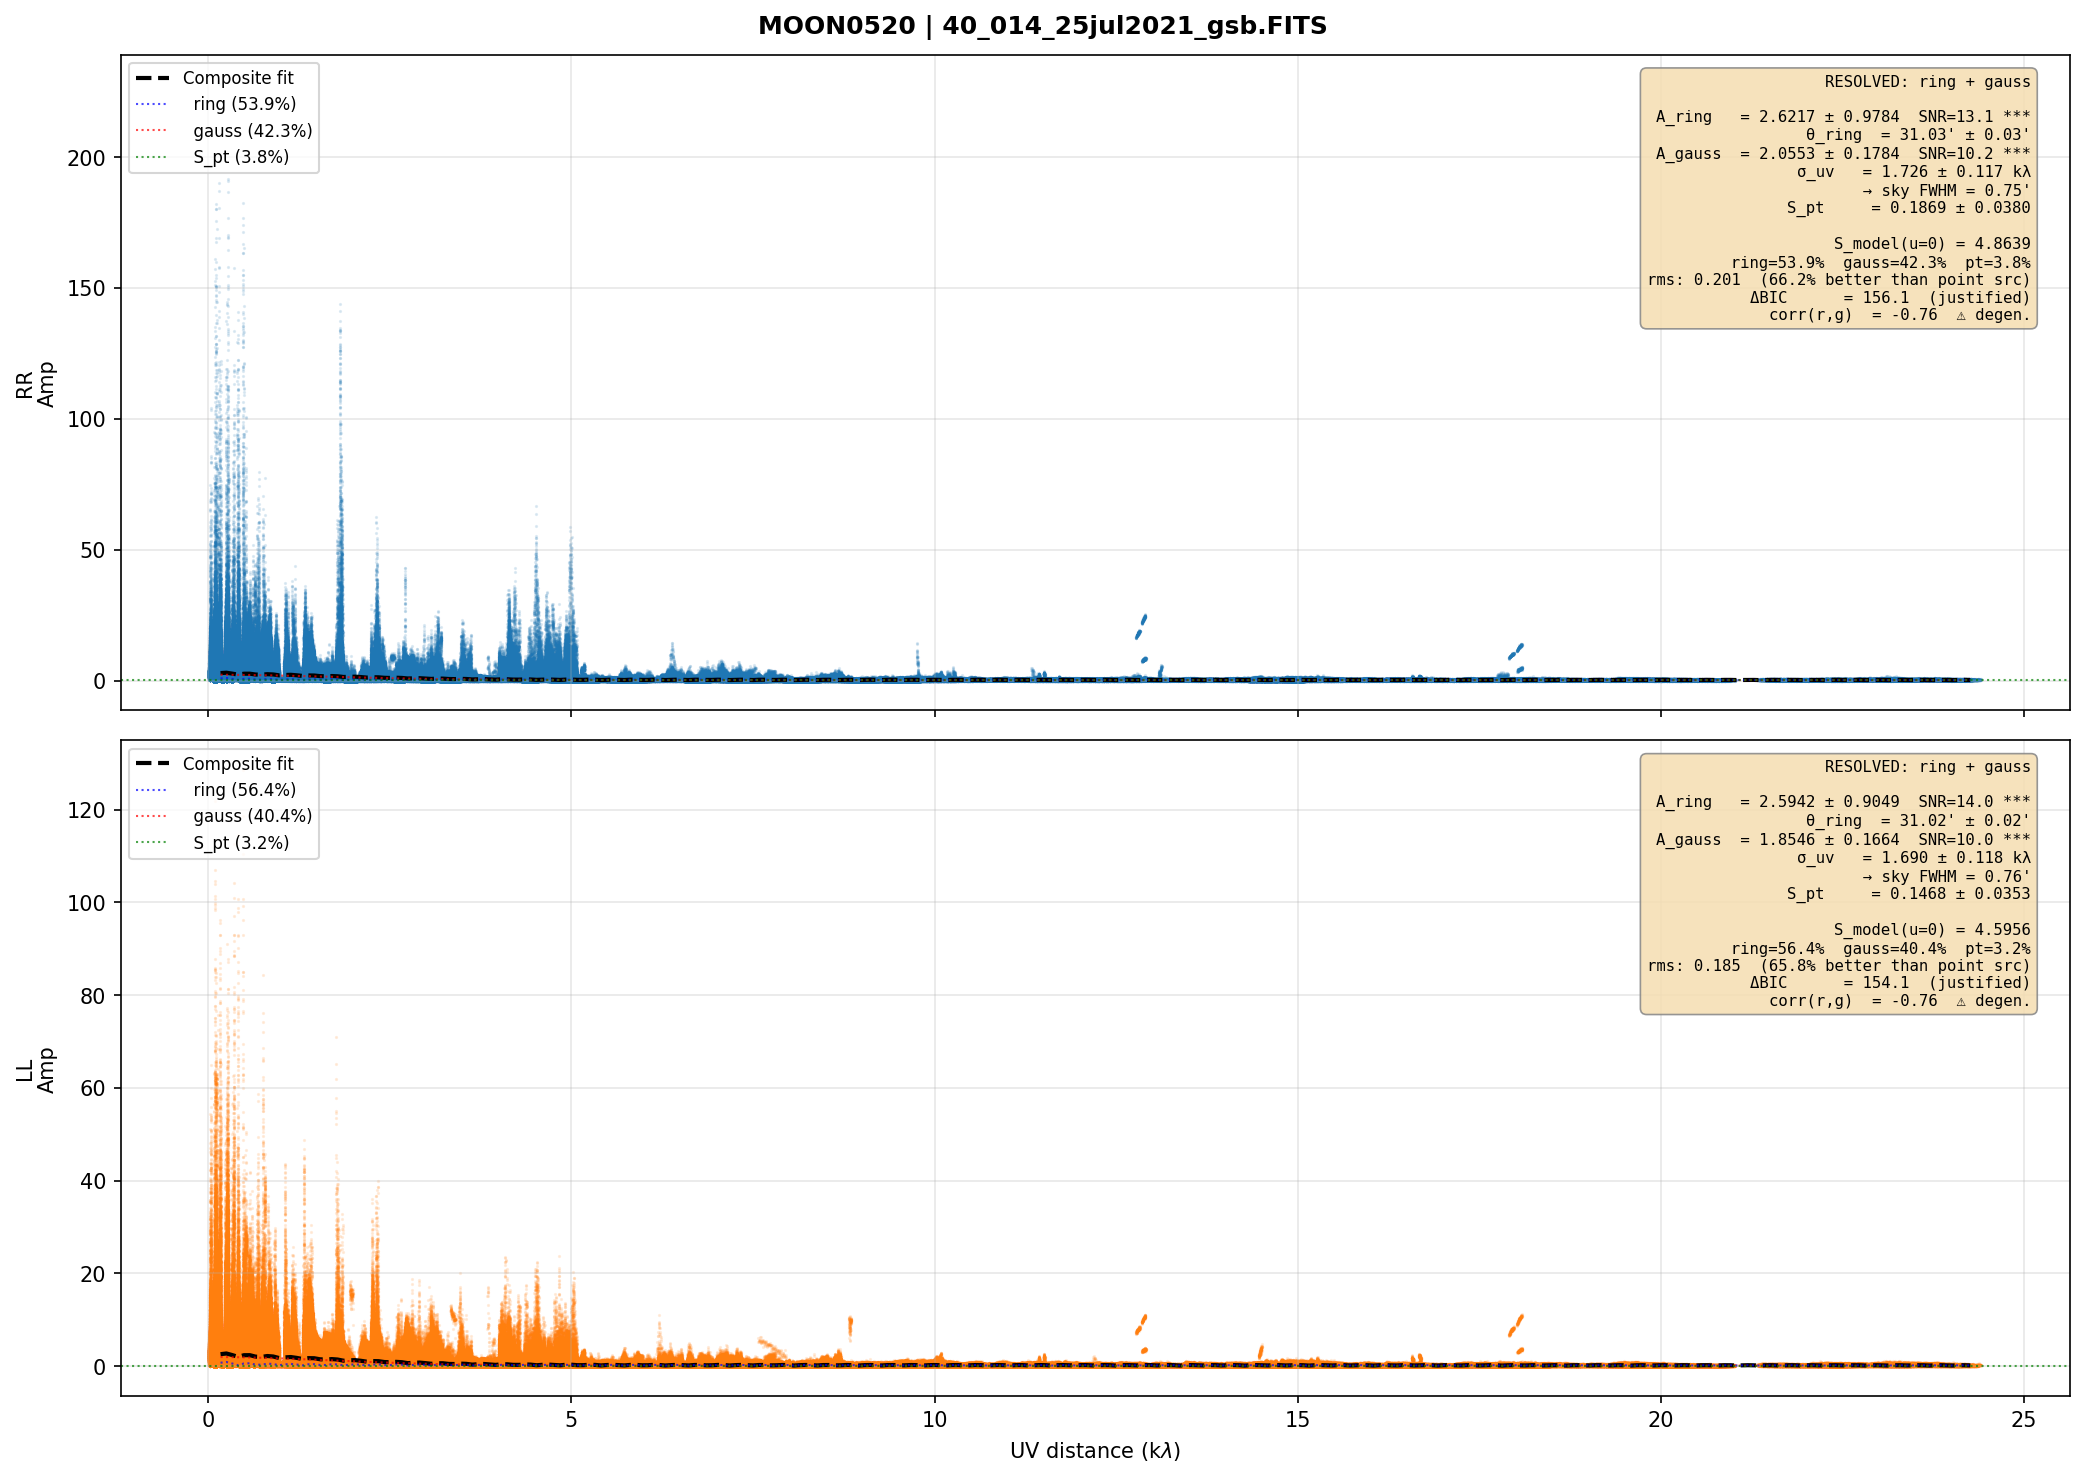

In [103]:
import importlib, sys

# Auto-reload so edits to ugmrt_query.py take effect without kernel restart
if 'ugmrt_query' in sys.modules:
    importlib.reload(sys.modules['ugmrt_query'])

from ugmrt_query import *


# USER CONFIGURATION - edit values below

VIS_FILE = Path(row_index['path'])
#SOURCE = '3C48'
SOURCE='MOON0520'

# Memory-safe defaults: narrower antenna set, mid-band channels, two correlations
# NOTE: GSB files have only 256 channels, so use valid range (0-255)
ANT_RANGE = None #(1, 16)
ANT_LIST = None #[1, 2, 28]  # None
CHAN_RANGE = (64, 191)  # Restrict to mid-band: 128 of 256 channels
STOKES = ['RR', 'LL']
MAX_ROWS = 30_000
SHOW_PHASE = False

# Choose fit model: 'disk', 'ring', 'annulus', 'composite', 'gaussian', or None
#FIT_MODEL = 'ring'      # thin ring (limb-bright Moon)
#FIT_MODEL = 'annulus'   # thick annulus (bright rim, dark interior)
FIT_MODEL = 'composite' # ring (thermal limb) + central Gaussian (reflected Earth RFI)
#FIT_MODEL = 'disk'      # classic uniform disk

print(f'File   : {VIS_FILE.name}')
print(f'Source : {SOURCE}')
print(f'Antenna: range={ANT_RANGE}, list={ANT_LIST}')
print(f'Chans  : {CHAN_RANGE}, Stokes={STOKES}, max_rows={MAX_ROWS}')
print(f'Fit    : {FIT_MODEL}')

vis = load_vis_for_source(
    row_index,
    source=SOURCE,
    ant_range=ANT_RANGE,
    ant_list=ANT_LIST,
    chan_range=CHAN_RANGE,
    stokes=STOKES,
    max_rows=MAX_ROWS,
)

print(f'\nLoaded rows: {vis["nrows"]:,}')
print(f'Stokes: {vis["stokes_labels"]}')
print(
    f'Freq range: {vis["freqs_hz"].min()/1e6:.3f} - {vis["freqs_hz"].max()/1e6:.3f} MHz '
    f'({len(vis["freqs_hz"])} channels)')
print(f'Unique baselines: {len(set(zip(vis["ant1"], vis["ant2"])))}\n')

tag = f'{SOURCE} | {VIS_FILE.name}'
plot_vis_amp_vs_uvdist(vis, title=tag, show_phase=SHOW_PHASE, fit=FIT_MODEL)

In [ ]:
import importlib, sys, re

if 'ugmrt_query' in sys.modules:
    importlib.reload(sys.modules['ugmrt_query'])
from ugmrt_query import *

# --- settings ---
CHAN_RANGE = (64, 191)
STOKES = ['RR', 'LL']
MAX_ROWS = 30_000
FIT_MODEL = 'composite'
SAVE_DIR = Path('/media/wasim/gmrt_40_014/work')

# Find all MOON sources
all_sources = list_sources(target)
moon_sources = [s for s in all_sources
                if re.search(r'(?i)moon', s.get('source_name', ''))]
print(f'Found {len(moon_sources)} MOON source(s):',
      [s['source_name'] for s in moon_sources])

for src in moon_sources:
    sname = src['source_name']
    print(f'\n{"="*60}')
    print(f'Processing: {sname}')
    print(f'{"="*60}')

    vis = load_vis_for_source(
        row_index,
        source=sname,
        chan_range=CHAN_RANGE,
        stokes=STOKES,
        max_rows=MAX_ROWS,
    )
    print(f'Loaded rows: {vis["nrows"]:,}')

    tag = f'{sname} | {Path(row_index["path"]).name}'
    safe_name = sname.replace(' ', '_').replace('+', 'p')
    save_file = SAVE_DIR / f'uvdist_{safe_name}_{FIT_MODEL}.png'

    plot_vis_amp_vs_uvdist(
        vis, title=tag, fit=FIT_MODEL, save_path=str(save_file))


Found 5 MOON source(s): ['MOON0520', 'MOON0545', 'MOON0605', 'MOON0625', 'MOON0635']

Processing: MOON0520
[info] Downsampling: 42,714 -> ~42,714 rows (step=1)
[load_vis] 42,714 rows, 262 MB read, 8.0s
Loaded rows: 42,714
  [RR] Composite fit:
    A_ring   = 2.6217 +/- 0.9784  SNR=13.1  A/sig_fit=2.7  (53.9% of S_model)  *** SIGNIFICANT
    theta    = 31.03 +/- 0.03 arcmin
    A_gauss  = 2.0553 +/- 0.1784  SNR=10.2  A/sig_fit=11.5  (42.3% of S_model)  *** SIGNIFICANT
    sigma_uv = 1.726 +/- 0.117 klambda (=1726.1 lambda)  sky_sigma=0.32' sky_FWHM=0.75'
    S_pt     = 0.1869 +/- 0.0380  (3.8% of S_model)
    S_model(u=0) = 4.8639  (ring=53.9% + gauss=42.3% + pt=3.8%)  [model extrapolation]
    rms: 0.20076  (66.2% better than point src model,  rms_const=0.59429)
    corr(A_ring, A_gauss) = -0.761  *** degenerate
    delta_BIC=156.1  (composite justified)
    ==> RESOLVED: ring + gauss


## Step 11: Validate GSB vs GWB Channel Counts
Run the next cell to print channel counts and confirm backend differences.

In [ ]:
# Check channel counts for all files - GSB vs GWB
print(f"{'File':<50} {'nchan':>8} {'Type':<6}")
print('-' * 66)
for p in fits_files:
    fp = list_frequency_properties(p)
    nchan = fp['nchan']
    file_type = 'GSB' if 'gsb' in p.name.lower() else 'GWB'
    print(f"{p.name:<50} {nchan:>8} {file_type:<6}")
